# Meow: ML Training & Evaluation

Professional end-to-end notebook for classical ML on vibration windows using `MLEmbedder2`.
- Configurable dataset roots and labels
- Preprocess + feature embedding
- Train/val split, hyperparameter search
- Evaluation with confusion matrix + ROC
- Save best model to `weights/model_best.joblib`


In [41]:
import os
from pathlib import Path
import sys
import json
import random
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split, StratifiedKFold, GridSearchCV
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import accuracy_score, confusion_matrix, roc_curve, auc, classification_report
from sklearn.decomposition import PCA
from sklearn.svm import SVC
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.linear_model import LogisticRegression
import joblib


ROOT_CANDIDATES = [Path.cwd(), *Path.cwd().parents]
ROOT = next((p for p in ROOT_CANDIDATES if (p / "experiment").exists() and (p / "fdd_system").exists()), Path.cwd())
if str(ROOT) not in sys.path:
    sys.path.append(str(ROOT))
print("Project root:", ROOT)

from experiment.utils import prepare_training_data
from fdd_system.ML.common.config import SensorConfig
from fdd_system.ML.common.config import OperatingCondition
from fdd_system.ML.common.preprocessor import BasicPreprocessor
from fdd_system.ML.common.embedder import MLEmbedder2


Project root: /home/btanady/fourth_year/cpen491


In [42]:
# ==== Paths & labels ====
DATA_ROOT = ROOT / "experiment/data_8"  # adjust as needed
USE_INFLOW = False  # toggle if using inflow_blocked dir

normal_dir = DATA_ROOT / "normal"
blocked_dir = DATA_ROOT / ("inflow_blocked" if USE_INFLOW else "blocked")

SAVE_PATH = ROOT / "experiment/weights/model_best.joblib"
SEED = 42
BLOCKED_CLASS_WEIGHT = 0.25  # >1 ups weight of blocked samples during training
CLASS_WEIGHTS = {
    OperatingCondition.NORMAL.value: 1.0,
    OperatingCondition.BLOCKED_AIRFLOW.value: BLOCKED_CLASS_WEIGHT,
}
BLOCKED_BIAS = 1.0  # keep inference neutral by default

# Label mapping
label_map = {
    OperatingCondition.NORMAL.value: sorted([str(p) for p in normal_dir.glob("*.csv")]),
    OperatingCondition.BLOCKED_AIRFLOW.value: sorted([str(p) for p in blocked_dir.glob("*.csv")]),
}

train_ratio = 0.7
val_ratio = 0.15  # remaining goes to test

random.seed(SEED)
np.random.seed(SEED)


In [43]:
def split_files(file_dict, train_ratio=0.7, val_ratio=0.15):
    train_files, val_files, test_files = {}, {}, {}
    for label, files in file_dict.items():
        files = list(files)
        random.shuffle(files)
        n = len(files)
        n_train = int(train_ratio * n)
        n_val = int(val_ratio * n)
        train_files[label] = files[:n_train]
        val_files[label] = files[n_train:n_train + n_val]
        test_files[label] = files[n_train + n_val:]
    return train_files, val_files, test_files

train_files, val_files, test_files = split_files(label_map, train_ratio, val_ratio)
print("File split counts:")
for name, group in [("train", train_files), ("val", val_files), ("test", test_files)]:
    print(name, {k: len(v) for k, v in group.items()})


File split counts:
train {0: 13, 1: 13}
val {0: 2, 1: 2}
test {0: 4, 1: 4}


In [44]:
def to_windows(file_map):
    return prepare_training_data(file_map, shuffle=True, col_names=["X", "Y", "Z"])

train_raw = to_windows(train_files)
val_raw = to_windows(val_files)
test_raw = to_windows(test_files)

print(f"windows: train={len(train_raw)}, val={len(val_raw)}, test={len(test_raw)}")


windows: train=1766, val=276, test=552


In [45]:
pre = BasicPreprocessor()
embedder = MLEmbedder2()

train_pre = pre.preprocess(train_raw)
val_pre = pre.preprocess(val_raw)
test_pre = pre.preprocess(test_raw)

X_train = embedder.embed(train_pre)
X_val = embedder.embed(val_pre)
X_test = embedder.embed(test_pre)

feat_names = embedder.feat_names

y_train = np.array([w.label for w in train_pre])
y_val = np.array([w.label for w in val_pre])
y_test = np.array([w.label for w in test_pre])

print("Features shape:", X_train.shape, "#feat=", len(feat_names))


Features shape: (1766, 72) #feat= 72


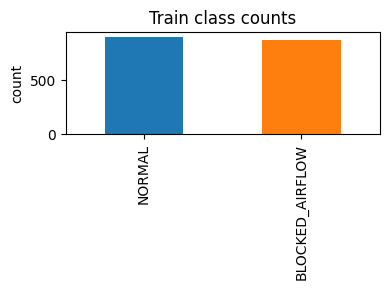

In [46]:
# Class distribution
fig, ax = plt.subplots(figsize=(4,3))
counts = pd.Series(y_train).value_counts().sort_index()
counts.index = [OperatingCondition(i).name for i in counts.index]
counts.plot(kind='bar', ax=ax, color=['C0','C1','C2'])
ax.set_ylabel('count'); ax.set_title('Train class counts');
plt.tight_layout(); plt.show()


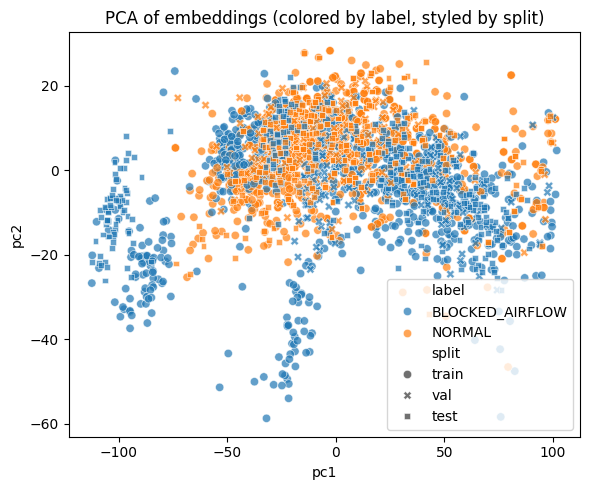

PCA explained variance (2D): 0.83


In [47]:
# ==== Embedding visualization (PCA) ====
X_vis = np.vstack([X_train, X_val, X_test])
y_vis = np.concatenate([y_train, y_val, y_test])
split_vis = (['train'] * len(train_pre)) + (['val'] * len(val_pre)) + (['test'] * len(test_pre))

pca = PCA(n_components=2, random_state=SEED)
coords = pca.fit_transform(X_vis)
vis_df = pd.DataFrame({
    'pc1': coords[:,0],
    'pc2': coords[:,1],
    'label': [OperatingCondition(v).name for v in y_vis],
    'split': split_vis,
})

fig, ax = plt.subplots(figsize=(6,5))
sns.scatterplot(data=vis_df, x='pc1', y='pc2', hue='label', style='split', alpha=0.7, ax=ax)
ax.set_title('PCA of embeddings (colored by label, styled by split)')
plt.tight_layout()
plt.show()
print(f"PCA explained variance (2D): {pca.explained_variance_ratio_.sum():.2f}")


In [48]:
# ==== Model search ====
scorer = 'accuracy'
cv = StratifiedKFold(n_splits=3, shuffle=True, random_state=SEED)

models = {
    'svm_rbf': {
        'est': Pipeline([
            ('scaler', StandardScaler()),
            ('clf', SVC(probability=True, class_weight=CLASS_WEIGHTS)),
        ]),
        'params': {
            'clf__C': [0.5, 1.0, 2.0, 5.0],
            'clf__gamma': ['scale', 'auto'],
        },
    },
    'rf': {
        'est': RandomForestClassifier(class_weight=CLASS_WEIGHTS, random_state=SEED),
        'params': {
            'n_estimators': [200, 400],
            'max_depth': [None, 10, 20],
            'min_samples_leaf': [1, 2, 4],
        },
    },
    'gb': {
        'est': GradientBoostingClassifier(random_state=SEED),
        'params': {
            'n_estimators': [200, 400],
            'learning_rate': [0.05, 0.1],
            'max_depth': [2, 3],
        },
    },
    'logreg': {
        'est': Pipeline([
            ('scaler', StandardScaler()),
            ('clf', LogisticRegression(max_iter=200, class_weight=CLASS_WEIGHTS)),
        ]),
        'params': {
            'clf__C': [0.5, 1.0, 2.0],
            'clf__penalty': ['l2'],
        },
    },
}

search_results = []
best_clf = None
best_name = None
best_score = -np.inf

X_tr = np.vstack([X_train, X_val])
y_tr = np.concatenate([y_train, y_val])

# Sample weights to bias blocked class during training
sample_weights = np.where(y_tr == OperatingCondition.BLOCKED_AIRFLOW.value, BLOCKED_CLASS_WEIGHT, 1.0)
fit_params_map = {
    'svm_rbf': {'clf__sample_weight': sample_weights},
    'rf': {'sample_weight': sample_weights},
    'gb': {'sample_weight': sample_weights},
    'logreg': {'clf__sample_weight': sample_weights},
}

for name, cfg in models.items():
    gscv = GridSearchCV(
        cfg['est'], cfg['params'], cv=cv, scoring=scorer, n_jobs=-1, verbose=0
    )
    fit_params = fit_params_map.get(name, {})
    gscv.fit(X_tr, y_tr, **fit_params)
    mean_acc = gscv.best_score_
    search_results.append((name, mean_acc, gscv.best_params_))
    if mean_acc > best_score:
        best_score = mean_acc
        best_clf = gscv.best_estimator_
        best_name = name

search_df = pd.DataFrame(search_results, columns=['model', 'cv_acc', 'best_params'])
print(search_df.sort_values('cv_acc', ascending=False))
print(f"Selected: {best_name} | cv_acc={best_score:.3f}")


     model    cv_acc                                        best_params
2       gb  0.959199  {'learning_rate': 0.1, 'max_depth': 2, 'n_esti...
1       rf  0.938994  {'max_depth': 20, 'min_samples_leaf': 4, 'n_es...
0  svm_rbf  0.824686             {'clf__C': 5.0, 'clf__gamma': 'scale'}
3   logreg  0.822234              {'clf__C': 2.0, 'clf__penalty': 'l2'}
Selected: gb | cv_acc=0.959


In [49]:
# ==== Prediction bias helper ====
def predict_with_bias(model, X, bias=BLOCKED_BIAS):
    """Return predictions (and probs if available) with optional bias toward blocked."""
    probs = None
    if hasattr(model, 'predict_proba'):
        probs = model.predict_proba(X)
    elif hasattr(model, 'decision_function'):
        margins = np.asarray(model.decision_function(X))
        if margins.ndim == 1:
            margins = margins.reshape(-1, 1)
        if margins.shape[1] == 1:
            pos = 1 / (1 + np.exp(-margins[:, 0]))
            probs = np.stack([1 - pos, pos], axis=1)
        else:
            probs = margins
    if probs is not None and probs.ndim == 2 and probs.shape[1] >= 2:
        probs = probs.astype(float)
        probs[:, OperatingCondition.BLOCKED_AIRFLOW.value] *= bias
        probs = probs / probs.sum(axis=1, keepdims=True)
        y_pred = np.argmax(probs, axis=1)
    else:
        y_pred = model.predict(X)
    return y_pred, probs


val: acc=0.996 (bias=1.00)
              precision    recall  f1-score   support

      NORMAL       0.99      1.00      1.00       138
     BLOCKED       1.00      0.99      1.00       138

    accuracy                           1.00       276
   macro avg       1.00      1.00      1.00       276
weighted avg       1.00      1.00      1.00       276



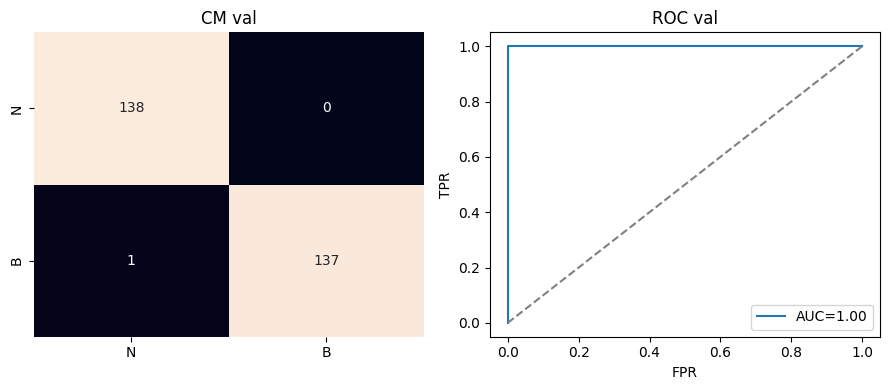

test: acc=0.971 (bias=1.00)
              precision    recall  f1-score   support

      NORMAL       0.95      0.99      0.97       276
     BLOCKED       0.99      0.95      0.97       276

    accuracy                           0.97       552
   macro avg       0.97      0.97      0.97       552
weighted avg       0.97      0.97      0.97       552



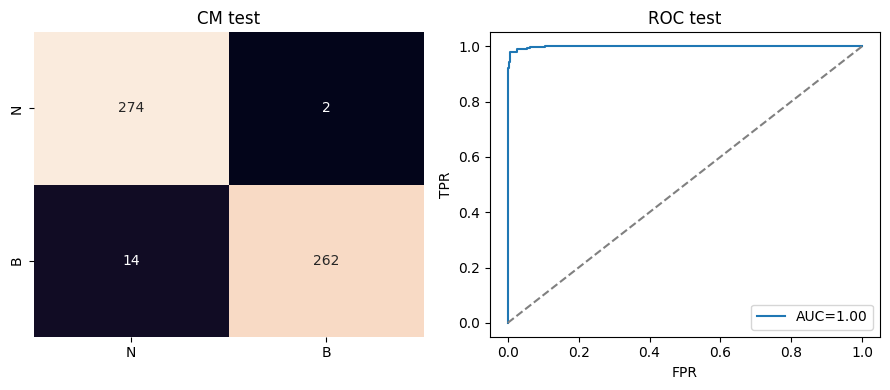

In [50]:
def evaluate(model, X, y, title="eval", bias=BLOCKED_BIAS):
    y_pred, probs = predict_with_bias(model, X, bias=bias)
    acc = accuracy_score(y, y_pred)
    cm = confusion_matrix(y, y_pred, labels=[OperatingCondition.NORMAL.value, OperatingCondition.BLOCKED_AIRFLOW.value])
    print(f"{title}: acc={acc:.3f} (bias={bias:.2f})")
    print(classification_report(y, y_pred, target_names=['NORMAL','BLOCKED']))
    fig, ax = plt.subplots(1,2, figsize=(9,4))
    sns.heatmap(cm, annot=True, fmt='d', cbar=False, ax=ax[0], xticklabels=['N','B'], yticklabels=['N','B'])
    ax[0].set_title(f"CM {title}")
    # ROC
    if probs is not None and probs.shape[1] > OperatingCondition.BLOCKED_AIRFLOW.value:
        pos_probs = probs[:, OperatingCondition.BLOCKED_AIRFLOW.value]
    else:
        pos_probs = np.zeros_like(y, dtype=float)
    fpr, tpr, _ = roc_curve(y, pos_probs, pos_label=OperatingCondition.BLOCKED_AIRFLOW.value)
    ax[1].plot(fpr, tpr, label=f"AUC={auc(fpr,tpr):.2f}")
    ax[1].plot([0,1],[0,1],'--',color='gray')
    ax[1].legend(); ax[1].set_title(f"ROC {title}"); ax[1].set_xlabel('FPR'); ax[1].set_ylabel('TPR');
    plt.tight_layout(); plt.show()
    return acc

val_acc = evaluate(best_clf, X_val, y_val, title="val")
test_acc = evaluate(best_clf, X_test, y_test, title="test")


In [51]:
SAVE_PATH.parent.mkdir(parents=True, exist_ok=True)
metadata = {
    'feature_names': feat_names,
    'embedder': 'MLEmbedder2',
    'sensor': {
        'sampling_rate': SensorConfig.SAMPLING_RATE,
        'window_size': SensorConfig.WINDOW_SIZE,
        'stride': SensorConfig.STRIDE,
    },
    'model_name': best_name,
}
joblib.dump(best_clf, SAVE_PATH)
print(f"Saved best model to {SAVE_PATH}")


Saved best model to /home/btanady/fourth_year/cpen491/experiment/weights/model_best.joblib
